In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [79]:
df = sns.load_dataset("titanic")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [62]:
df.describe()
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

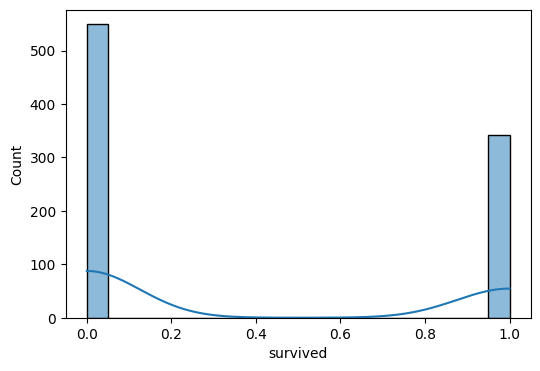

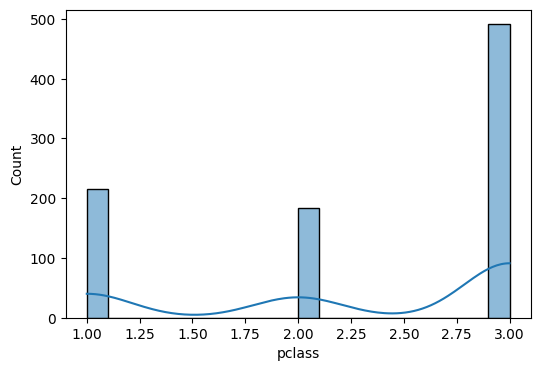

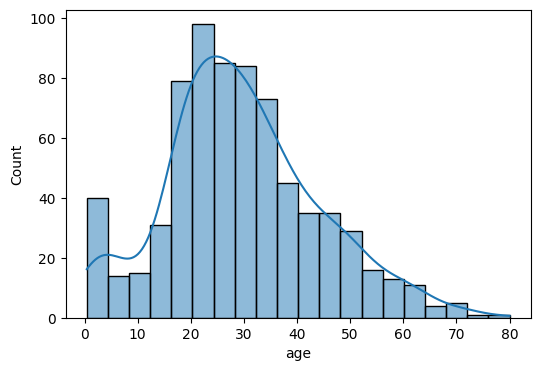

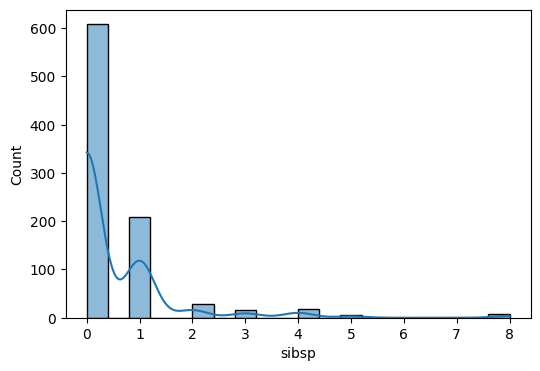

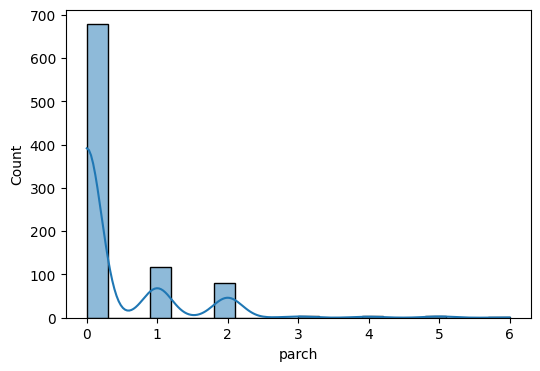

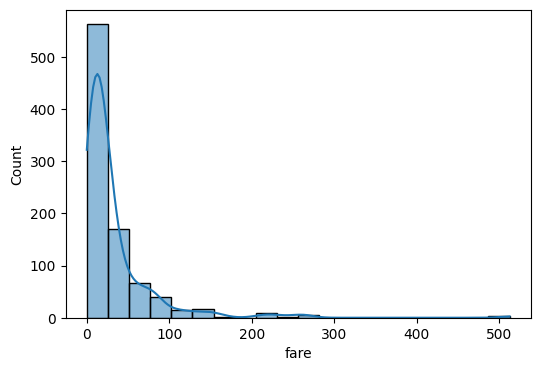

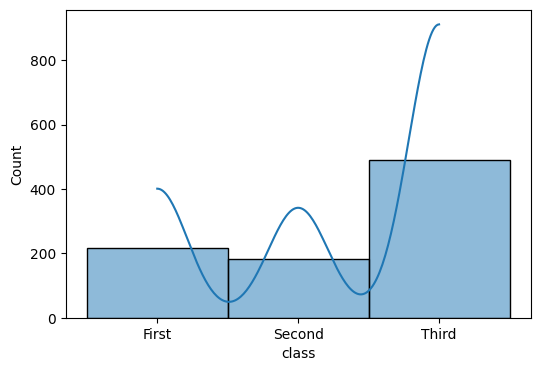

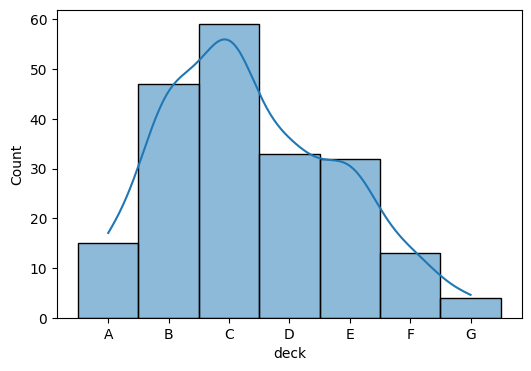

In [80]:
numeric_columns = ['survived', 'pclass','age', 'sibsp', 'parch', 'fare','class','deck',]
for cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[cols],kde=True,bins=20)

<Axes: xlabel='embarked', ylabel='sex'>

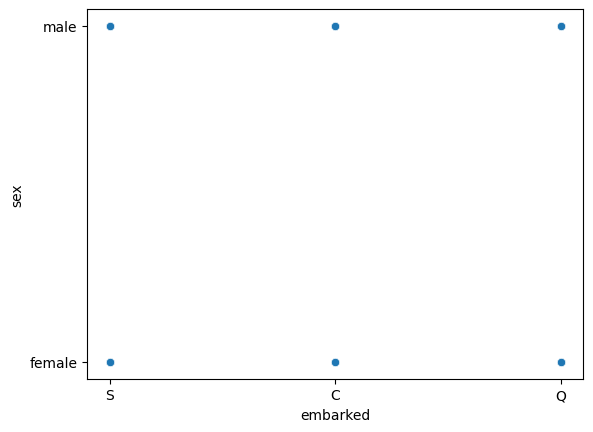

In [64]:
sns.scatterplot(df,x='embarked',y='sex')

In [81]:
df_cleaned = df.copy()
df_cleaned.shape

(891, 15)

In [82]:
df_cleaned.drop(["deck", "embark_town", "alive", "class"], axis=1, inplace=True)

In [67]:
df_cleaned.shape

(891, 11)

In [68]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    object 
 3   age         714 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   embarked    889 non-null    object 
 8   who         891 non-null    object 
 9   adult_male  891 non-null    bool   
 10  alone       891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 64.5+ KB


In [83]:
df_cleaned["age"].fillna(df_cleaned["age"].mean(),inplace=True)
df_cleaned.dropna(subset=['embarked'],inplace=True)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    889 non-null    int64  
 1   pclass      889 non-null    int64  
 2   sex         889 non-null    object 
 3   age         889 non-null    float64
 4   sibsp       889 non-null    int64  
 5   parch       889 non-null    int64  
 6   fare        889 non-null    float64
 7   embarked    889 non-null    object 
 8   who         889 non-null    object 
 9   adult_male  889 non-null    bool   
 10  alone       889 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(3)
memory usage: 71.2+ KB


In [84]:
df_cleaned.drop_duplicates(inplace=True)
df_cleaned.shape

(778, 11)

In [71]:
df_cleaned['who'].value_counts()

who
man      448
woman    248
child     82
Name: count, dtype: int64

In [85]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_cleaned["sex"]=le.fit_transform(df_cleaned['sex'])
df_cleaned

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,0,3,1,22.000000,1,0,7.2500,S,man,True,False
1,1,1,0,38.000000,1,0,71.2833,C,woman,False,False
2,1,3,0,26.000000,0,0,7.9250,S,woman,False,True
3,1,1,0,35.000000,1,0,53.1000,S,woman,False,False
4,0,3,1,35.000000,0,0,8.0500,S,man,True,True
...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,0,39.000000,0,5,29.1250,Q,woman,False,False
887,1,1,0,19.000000,0,0,30.0000,S,woman,False,True
888,0,3,0,29.699118,1,2,23.4500,S,woman,False,False
889,1,1,1,26.000000,0,0,30.0000,C,man,True,True


In [86]:
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns = ['embarked','alone', "who", "adult_male"],
    drop_first = True,
    dtype =int)
df_cleaned.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,alone_True,who_man,who_woman,adult_male_True
0,0,3,1,22.0,1,0,7.2500,0,1,0,1,0,1
1,1,1,0,38.0,1,0,71.2833,0,0,0,0,1,0
2,1,3,0,26.0,0,0,7.9250,0,1,1,0,1,0
3,1,1,0,35.0,1,0,53.1000,0,1,0,0,1,0
4,0,3,1,35.0,0,0,8.0500,0,1,1,1,0,1


In [87]:
from sklearn.preprocessing import StandardScaler
col = ['age','fare','pclass']
scaler = StandardScaler()
df_cleaned[col] = scaler.fit_transform(df_cleaned[col])
df_cleaned


,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,alone_True,who_man,who_woman,adult_male_True
0,0,0.880357,1,-0.566794,1,0,-0.525640,0,1,0,1,0,1
1,1,-1.465252,0,0.604016,1,0,0.699954,0,0,0,0,1,0
2,1,0.880357,0,-0.274091,0,0,-0.512721,0,1,1,0,1,0
3,1,-1.465252,0,0.384489,1,0,0.351927,0,1,0,0,1,0
4,0,0.880357,1,0.384489,0,0,-0.510328,0,1,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,0.880357,0,0.677191,0,5,-0.106954,1,0,0,0,1,0
887,1,-1.465252,0,-0.786320,0,0,-0.090206,0,1,1,0,1,0
888,0,0.880357,0,-0.003406,1,2,-0.215573,0,1,0,0,1,0
889,1,-1.465252,1,-0.274091,0,0,-0.090206,0,0,1,1,0,1


In [88]:
from sklearn.model_selection import train_test_split
x = df_cleaned.drop('survived',axis=1)
y = df_cleaned['survived']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1234)

In [89]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [90]:
y_pred = model.predict(x_test)

In [91]:
y_pred

array([1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0,
       0, 0])

In [99]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
acc = accuracy_score(y_test,y_pred)
print("Accuracy is :",acc)
print("confusion matrix is :",confusion_matrix(y_test,y_pred))
print("classification report is:",classification_report(y_test,y_pred))

Accuracy is : 0.8012820512820513
confusion matrix is : [[82 14]
 [17 43]]
classification report is:               precision    recall  f1-score   support

           0       0.83      0.85      0.84        96
           1       0.75      0.72      0.74        60

    accuracy                           0.80       156
   macro avg       0.79      0.79      0.79       156
weighted avg       0.80      0.80      0.80       156

